# Experiment 2 (MNIST): Lipschitz Estimation on Real Classifiers

## Motivation and relation to Experiment 1

Experiment 1 (`toy_lipschitz`, sibling folder) built three ways to estimate
a function's **Lipschitz constant** `L` -- how much its output can change
for a given change in input, `|f(x')-f(x)| <= L * ||x'-x||` -- and
validated all three against a **known, closed-form ground truth** `L*` on
a toy 1D/2D regression problem. It also showed that replacing plain
Euclidean distance with a **Mahalanobis distance** fit from the data
itself can substantially change (and, there, improve) the resulting
estimate.

This experiment scales the same three estimators up to real classifiers
trained on MNIST. **There is no closed-form `L*` here** -- a trained
neural network's exact Lipschitz constant is not analytically knowable in
general. So this experiment cannot ask "how close is the estimate to the
truth"; it can only ask two weaker but still meaningful questions:

1. **Do the three independent sub-methods (pairwise, local-perturbation,
   gradient-norm) roughly agree with each other?** Disagreement doesn't
   necessarily mean a bug (see this notebook's results below -- it turns
   out they *don't* agree well here, and that's a real, reportable
   finding, not an error), but it tells you how much to trust any single
   number.
2. **Is the estimate stable under resampling?** An estimate that swings
   wildly depending on which random subset of the data it was computed
   from is fitting sampling noise, not a real property of the model.

These two checks -- sub-method agreement and subsample stability --
replace Experiment 1's "compare to `L*`" checkpoint everywhere in this
notebook.

**Out of scope for this experiment** (may return in a later one):
adversarial examples, FGSM/PGD attacks, robustness mitigations (weight
decay, spectral norm, gradient penalty, adversarial training, input
smoothing), Fashion-MNIST.

## What's being measured

Instead of a scalar regression output `f(x)` (Experiment 1), a classifier
outputs 10 logits. The Lipschitz estimators here are applied to the
**margin function**, `margin(x) = logit[y_true] - max(logit[j] for j !=
y_true)` -- the natural classifier analogue of a scalar output, and the
quantity robustness actually depends on: the margin crossing zero is
exactly where the predicted class flips.

Three classifiers are trained (logistic regression, a small MLP, a small
CNN), and for each, all three sub-methods are computed twice: once under
plain Euclidean distance, once under a **ridge-regularized Mahalanobis
distance** fit from MNIST's own pixel covariance (raw pixel covariance is
exactly singular -- many border pixels are 0 in every image -- so it must
be regularized before it can be inverted; how much regularization to use
is itself selected by a data-driven sweep, mirroring Experiment 1's
polynomial-embedding-degree selection).

This is a thin driver notebook -- all reusable logic lives in the sibling
`.py` modules (`data.py`, `models.py`, `estimators.py`, `distance.py`,
`run_experiment.py`, `plots.py`); this notebook only calls into them and
displays the results. See `README.md` in this folder for a plain
file-by-file reference of the codebase and the full write-up of what was
found.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from mnist_lipschitz import run_experiment, plots

## Running the full experiment

`run_mnist_experiment()` runs, in order:

1. **Train** logistic regression, MLP, and a small CNN on full MNIST.
2. **Euclidean-distance estimates**: all three sub-methods (pairwise,
   local-perturbation, gradient-norm), on all three models, evaluated on a
   fixed set of held-out test points.
3. **Epsilon selection**: fit the full-training-set pixel covariance,
   sweep several candidate ridge strengths (`epsilon`), and pick the
   smallest one whose regularized covariance is well-conditioned *and*
   whose resulting estimate is stable across independent random
   subsamples of the training data.
4. **Mahalanobis-distance estimates**: the same three sub-methods on the
   same three models, now under the selected Mahalanobis distance.
5. **Save** everything to `results/` (`mnist_experiment_results.json` for
   scalar summaries, `mnist_experiment_arrays.npz` for the full per-point
   arrays).

This takes about a minute on CPU.

In [2]:
results = run_experiment.run_mnist_experiment()

=== Step 1: training models ===


  epoch  1/15  train loss 0.8430
  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603
  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119
  epoch  6/15  train loss 0.2999


  epoch  7/15  train loss 0.2914
  epoch  8/15  train loss 0.2845


...

  mlp: pairwise=1.1760  local_max=0.3674  grad_max=16.0362  grad_mean=9.6752


  cnn: pairwise=1.1220  local_max=0.1897  grad_max=9.7031  grad_mean=5.3170

=== Step 4b: ratio-distribution analysis (Mahalanobis, epsilon=0.01, all models) ===


  [mahalanobis/logistic_regression] all-pairs ratio:        mean=0.1389  max=1.2492  n=499500
  [mahalanobis/logistic_regression] near-neighbor ratio:     mean=0.1078  max=1.0980  n=5000


  [mahalanobis/mlp] all-pairs ratio:        mean=0.1870  max=1.1762  n=499500
  [mahalanobis/mlp] near-neighbor ratio:     mean=0.1537  max=0.9965  n=5000


  [mahalanobis/cnn] all-pairs ratio:        mean=0.1983  max=1.1682  n=499500
  [mahalanobis/cnn] near-neighbor ratio:     mean=0.1508  max=0.8452  n=5000

Saved results to /Users/yichaowang/Documents/Part A/Datasig project/code/mnist_lipschitz/results


## Model accuracies

Sanity check before looking at any Lipschitz numbers: did training
actually work? (Thresholds validated in `tests/test_models.py`: logistic
regression > 90%, MLP > 96%, CNN > 98%, each with headroom below what's
typically observed.)

In [3]:
for name, acc in results["accuracies"].items():
    print(f"{name:20s} train_acc={acc['train']:.4f}  test_acc={acc['test']:.4f}")

logistic_regression  train_acc=0.9287  test_acc=0.9270
mlp                  train_acc=0.9931  test_acc=0.9782
cnn                  train_acc=0.9889  test_acc=0.9865


## Euclidean-distance estimates: do the three sub-methods agree?

Plain Euclidean distance in raw pixel space, for all three models. Each
panel below is one model; the three bars are the three independently
implemented sub-methods, on a log scale (they live on very different
natural scales here, which is itself part of the finding).

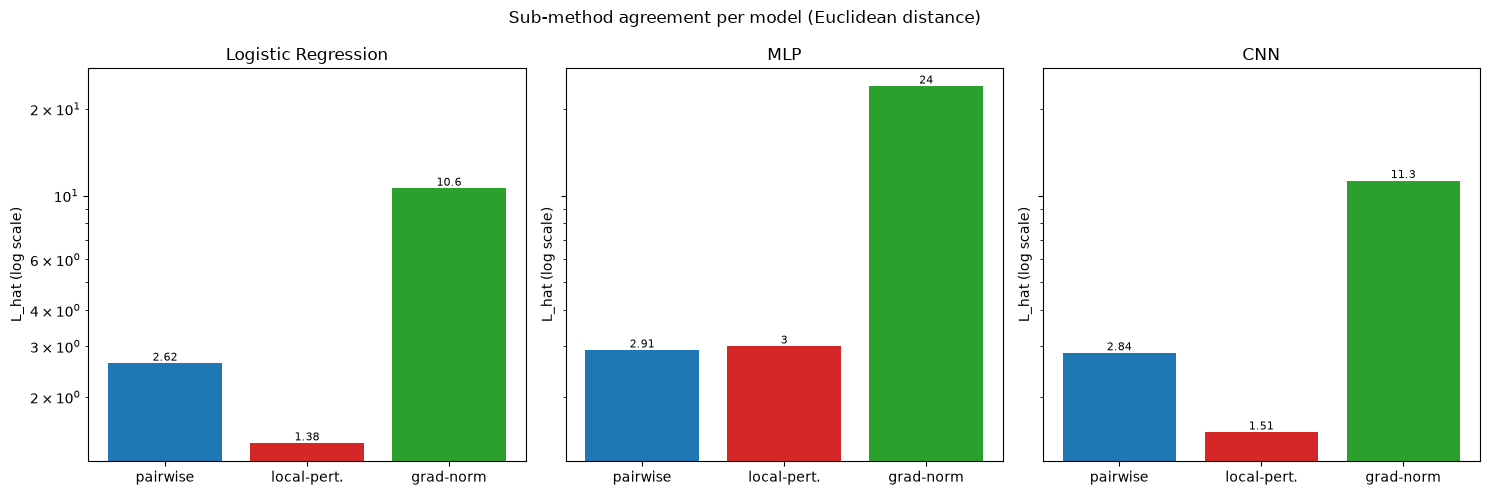

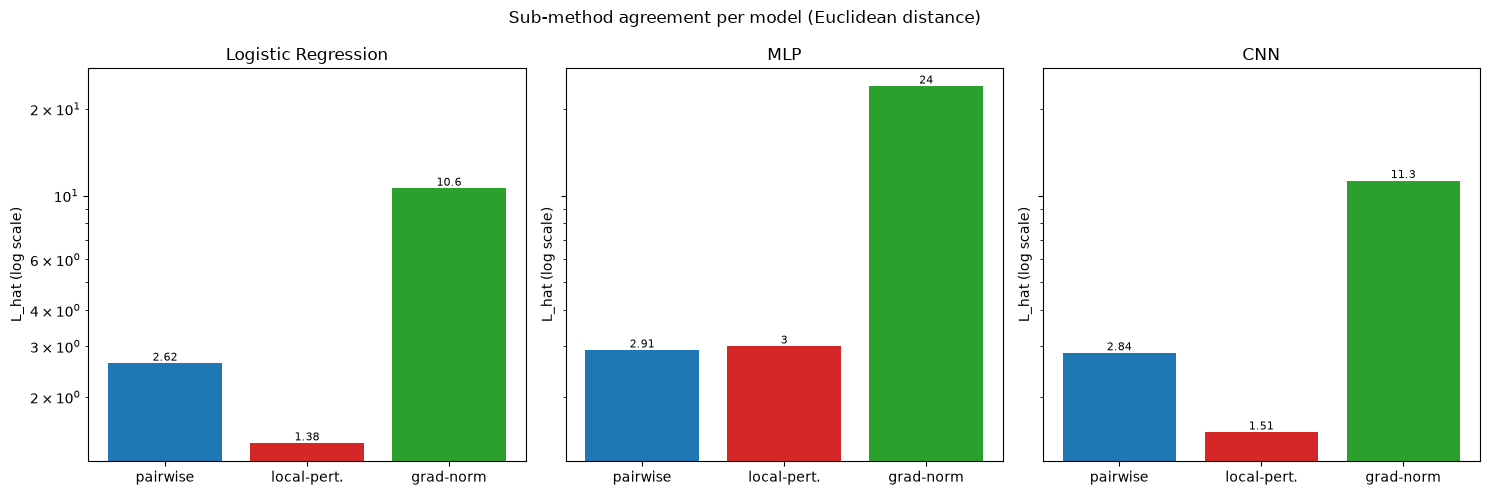

In [4]:
fig_agree_euclidean = plots.plot_submethod_agreement(
    results["euclidean_results"], metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_euclidean.png")
display(fig_agree_euclidean)

## Epsilon selection

MNIST's raw pixel covariance is exactly singular (constant-zero border
pixels), so it can't be inverted directly. The plot below shows, across a
range of candidate `epsilon` values (log scale): the condition number of
the ridge-regularized covariance (should shrink as epsilon grows -- always
true, this is a deterministic mathematical fact) and the coefficient of
variation of the resulting estimate across independent random subsamples
of the training set (should not get *worse* as epsilon grows -- this one
is an empirical check, not a mathematical guarantee, and is where a real
implementation bug would show up first). The selected epsilon (dashed
line) is the smallest one meeting both a condition-number bound and a
stability bound.

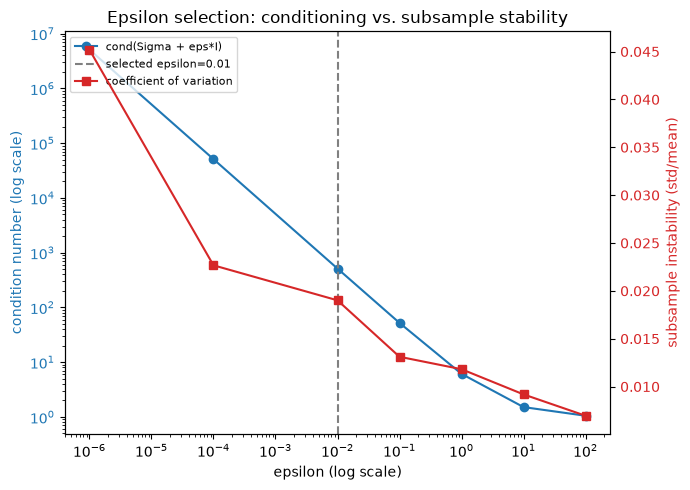

selected epsilon = 0.01


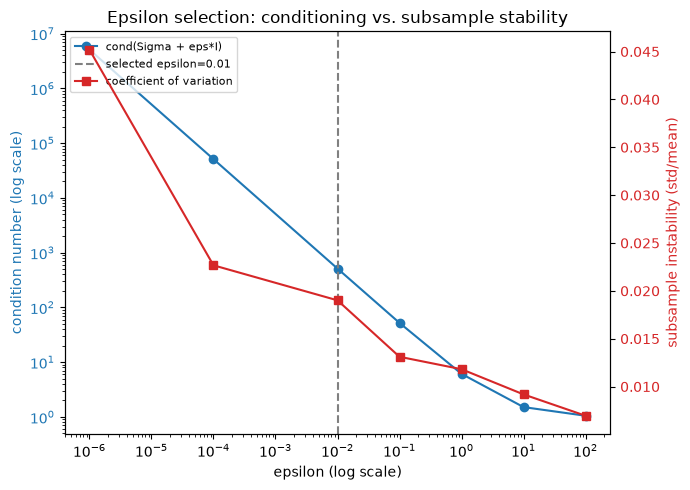

In [5]:
fig_epsilon = plots.plot_epsilon_sweep(
    results["epsilon_values"], results["cond_numbers"], results["cv_values"],
    selected_epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "epsilon_sweep.png")
display(fig_epsilon)
print(f"selected epsilon = {results['selected_epsilon']:g}")

## Why regularization is needed: the covariance's eigenvalue spectrum

The epsilon sweep above is a downstream *consequence* of a more basic
fact: MNIST's raw pixel covariance `Sigma` is singular. This section
makes that directly visible by plotting `Sigma`'s eigenvalue spectrum
(sorted largest to smallest, log scale), together with the
ridge-regularized spectrum `Sigma + epsilon*I` at the epsilon selected
above.

`Sigma + epsilon*I` has the *same eigenvectors* as `Sigma` -- adding
`epsilon*I` only shifts every eigenvalue up by exactly `epsilon` -- so the
two curves below differ only where `epsilon` actually matters: once an
eigenvalue of `Sigma` drops below `epsilon`, the regularized curve
flattens out at `epsilon` instead of continuing to fall, which is exactly
what keeps `(Sigma + epsilon*I)^{-1}` (the precision matrix used for
Mahalanobis distance) from blowing up in those directions.

largest eigenvalue:  5.1169
smallest eigenvalue: -6.7497e-16
eigenvalues below 1e-6: 94 / 784


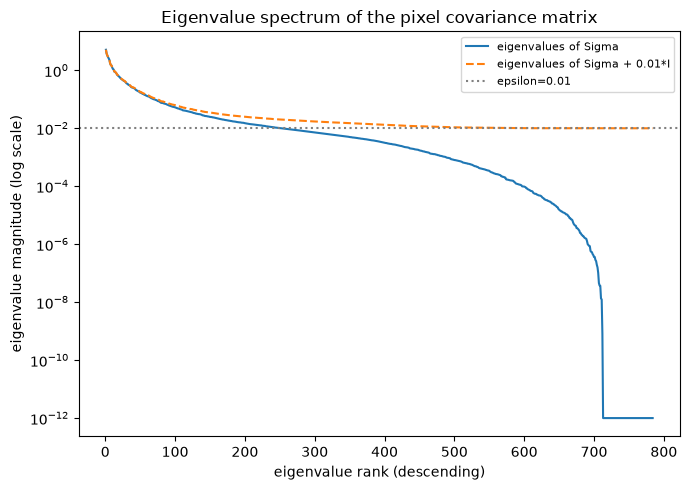

In [6]:
eigenvalues = results["covariance_eigenvalues"]
fig_eigenvalues = plots.plot_covariance_eigenvalues(
    eigenvalues, epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "covariance_eigenvalues.png")

n_near_zero = (eigenvalues < 1e-6).sum().item()
print(f"largest eigenvalue:  {eigenvalues[0].item():.4f}")
print(f"smallest eigenvalue: {eigenvalues[-1].item():.4e}")
print(f"eigenvalues below 1e-6: {n_near_zero} / {len(eigenvalues)}")

## Mahalanobis vs. Euclidean: does the metric change the estimates?

This is the central question of the experiment -- the same question
Experiment 1 asked on the toy problem, now on real classifiers. Same
three models, same three sub-methods, only the distance metric changes.

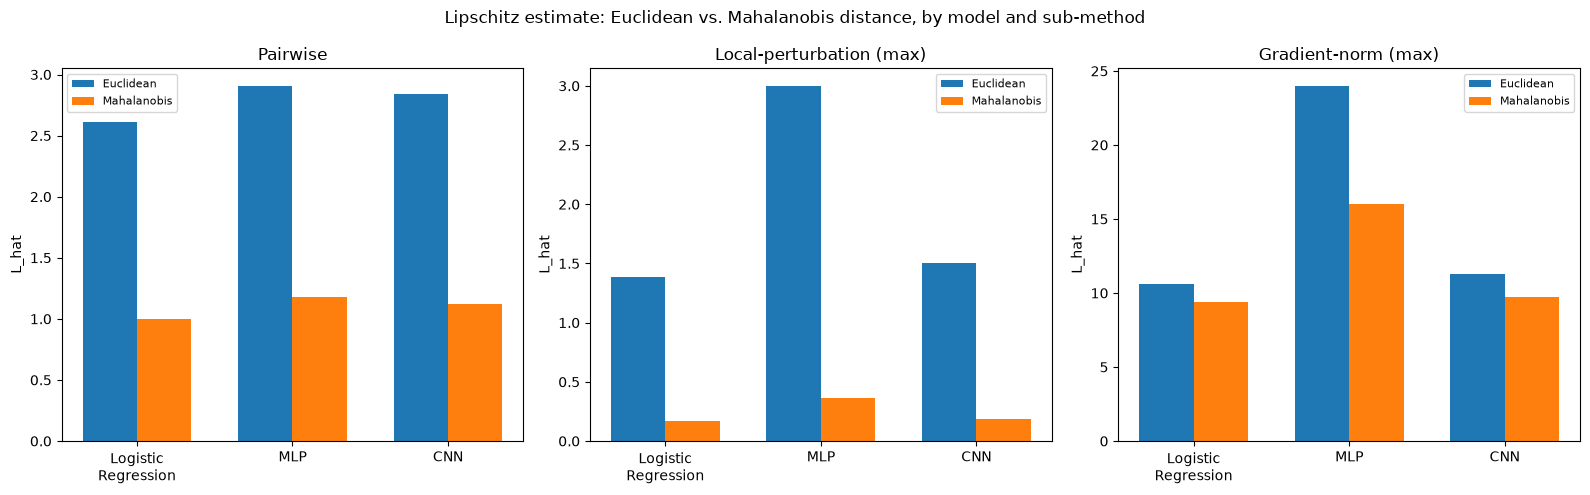

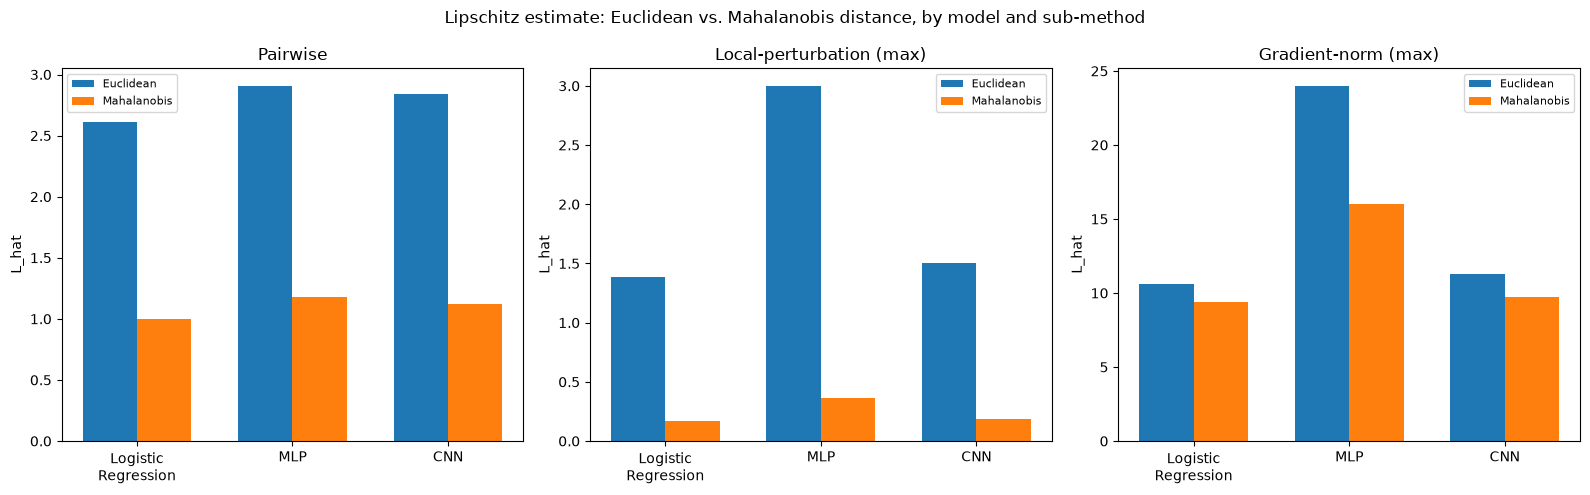

In [7]:
fig_compare = plots.plot_euclidean_vs_mahalanobis(
    results["euclidean_results"], results["mahalanobis_results"],
    save_path=run_experiment.RESULTS_DIR / "euclidean_vs_mahalanobis.png")
display(fig_compare)

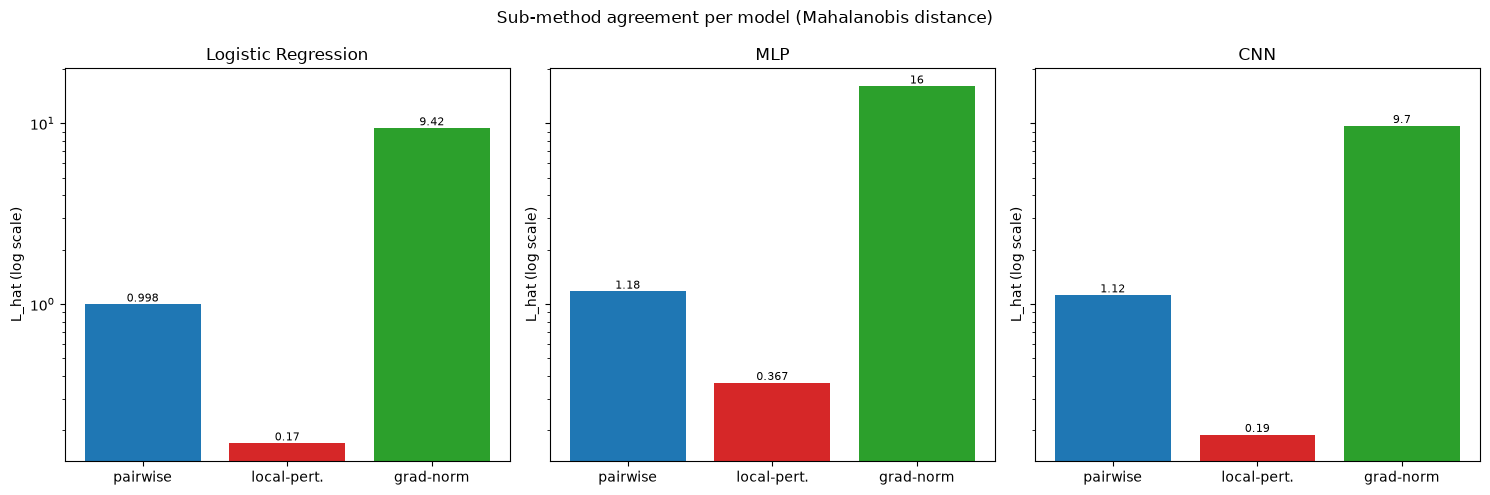

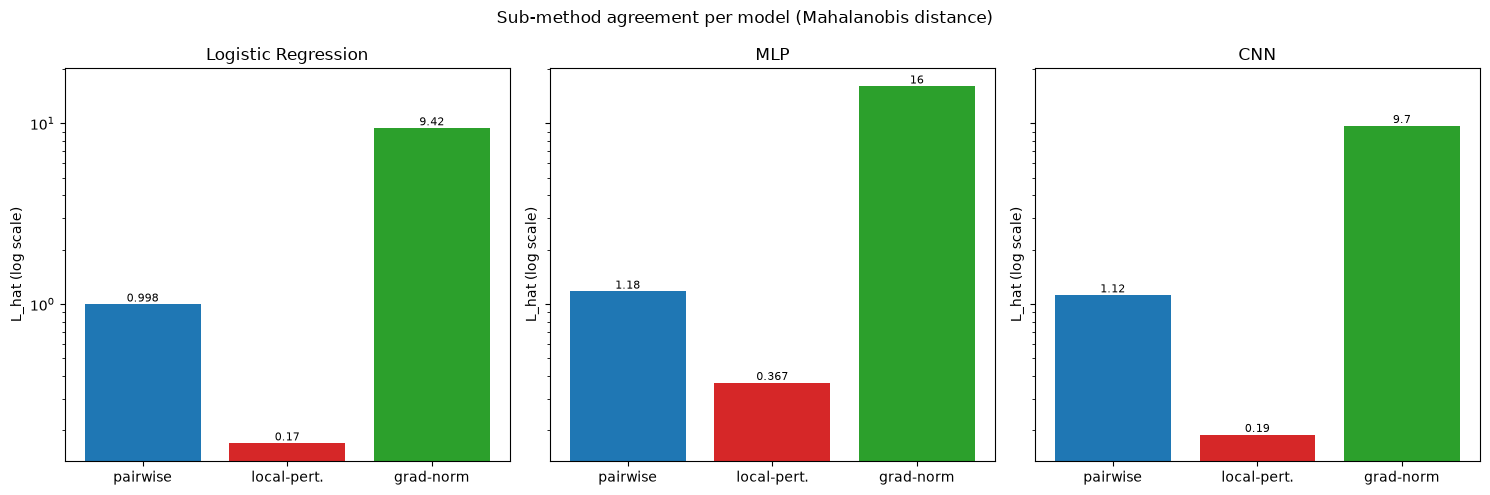

In [8]:
fig_agree_mahalanobis = plots.plot_submethod_agreement(
    results["mahalanobis_results"], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_mahalanobis.png")
display(fig_agree_mahalanobis)

## Ratio distribution and near-neighbour pairs

Every checkpoint above looks at a single summary number per model/metric
-- a max (`pairwise`), or a max/mean over a few hundred points. This
checkpoint instead looks at the full **distribution** of pairwise ratios,
`|margin_i - margin_j| / distance(x_i, x_j)`, computed over all pairs in
a **stratified sample** of 1000 test points (roughly 100 per digit, so no
class dominates by chance) that's disjoint from the 300-point sample used
above.

It then asks a more specific question: does that distribution look
different when restricted to **near-neighbour** pairs -- points that are
actually close together in raw pixel space (5-nearest-neighbours), rather
than arbitrary pairs of digits that may look nothing alike? This matters
because adversarial-style local stretch is a *local* phenomenon: the
ratio between two visually unrelated digits (a 1 and an 8 on opposite
sides of pixel space) says little about how sensitive the model is to a
*small* perturbation, whereas the ratio between two visually similar
images is closer to what a local Lipschitz constant is actually meant to
capture.

This is now run for **all three models**, under **Euclidean distance**.
The Mahalanobis distance is a planned follow-up, reusing the
epsilon/precision already selected below (Epsilon selection) rather than
re-running epsilon selection.

In [9]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 2b),
# for all three models -- run_ratio_distribution_analysis is directly callable with a
# different distance_fn (e.g. Mahalanobis) when extending further.
ratio_dist_euclidean_results = results["ratio_dist_euclidean_results"]

## Does the distribution shift near neighbours?

For each model: if near-neighbour pairs behaved just like a random pair
of digits, the two distributions in that model's panel below would
overlap almost exactly. If local stretch concentrates near visually
similar images, the near-neighbour curve should sit measurably to the
right of (or otherwise diverge from) the full distribution -- not
necessarily a dramatic difference, but a detectable one.

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    2.9369    0.3100    0.2542    0.2483
logistic_regression   near-neighbour         (5000,)    0.0002    2.9369    0.3488    0.2822    0.2897
mlp                   all pairs            (499500,)    0.0000    2.7766    0.4195    0.3460    0.3303
mlp                   near-neighbour         (5000,)    0.0001    2.7766    0.4974    0.4162    0.3867
cnn                   all pairs            (499500,)    0.0000    2.8369    0.4445    0.3768    0.3376
cnn                   near-neighbour         (5000,)    0.0003    2.8021    0.4876    0.3936    0.3941


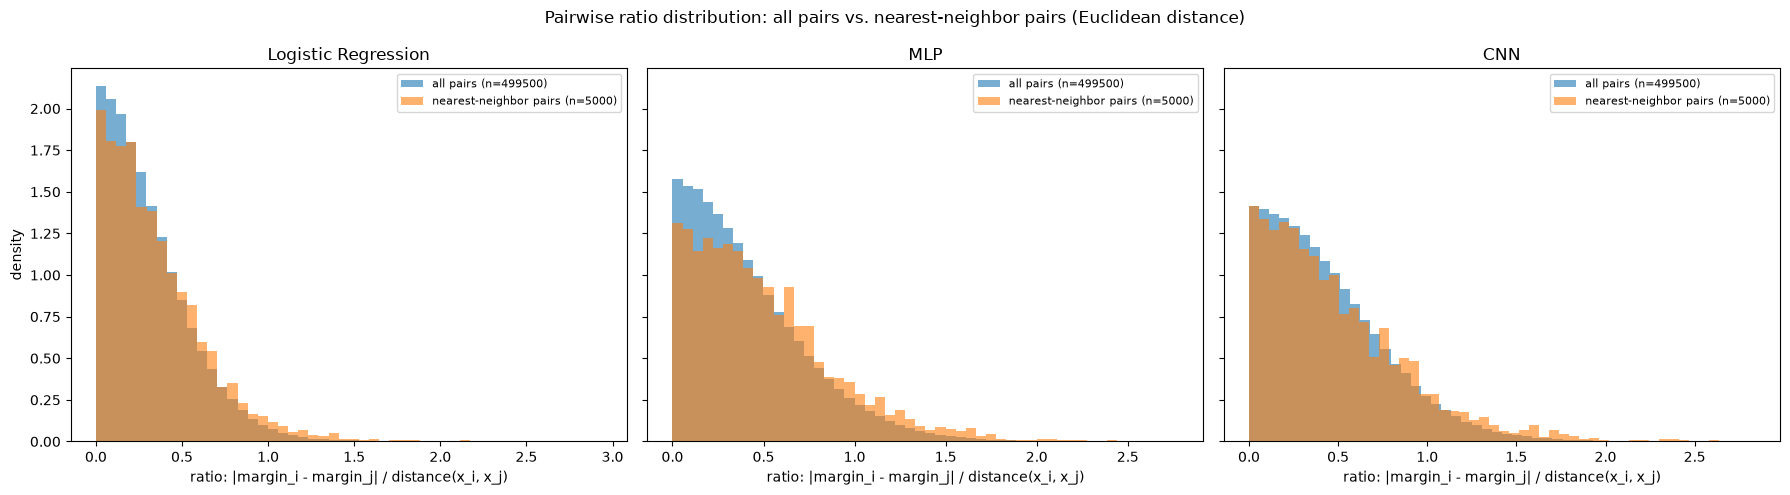

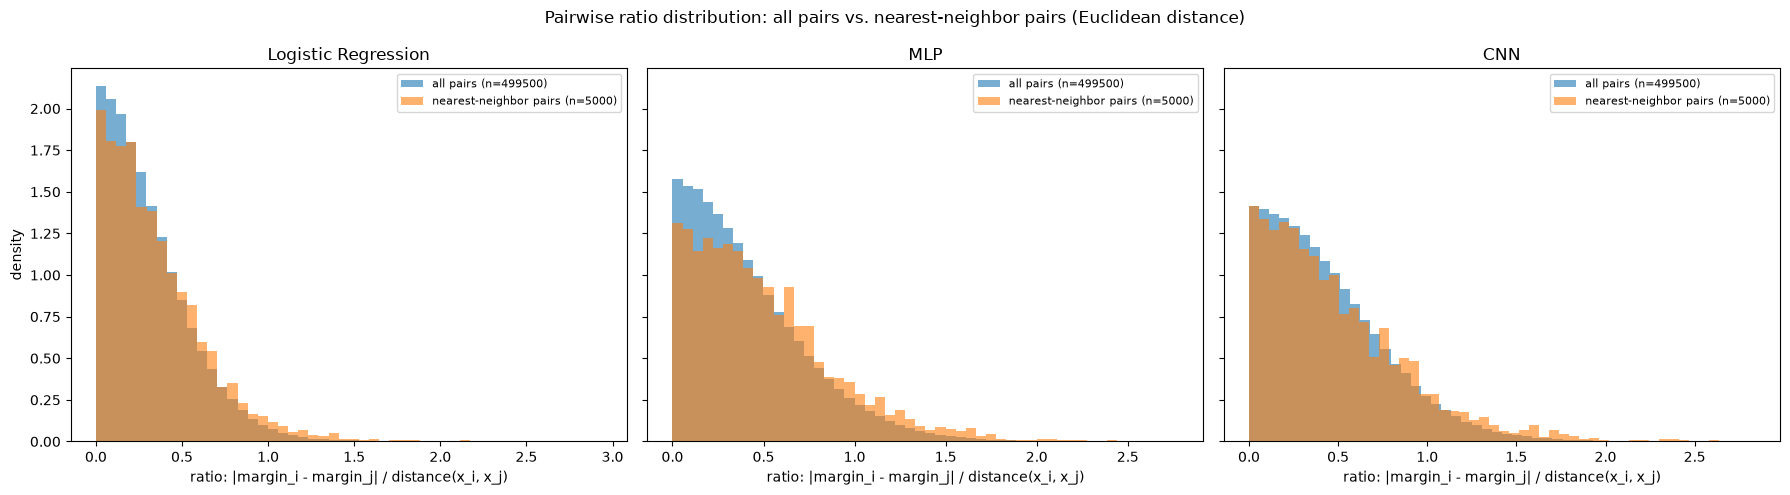

In [10]:
import numpy as np

print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_euclidean_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist = plots.plot_ratio_distribution(
    ratio_dist_euclidean_results, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution.png")
display(fig_ratio_dist)

## Highest-ratio near-neighbour pairs

The specific image pairs driving the upper tail of each model's
near-neighbour distribution above -- two pixel-similar digits that
model's margin treats very differently, the exact combination a
local-Lipschitz diagnostic is meant to flag. One gallery per model, shown
separately rather than as subplot panels on one figure (6 pairs x 2
images already fills a figure; three side by side would make each image
too small to actually look at). Each image is labeled with its true and
predicted class and the pair's ratio, deduplicated so a mutual
nearest-neighbour pair only counts once.

**Finding**: the *pattern* persists across all three models -- in every
case the top 6 are genuine cross-digit confusions, not degenerate or
nonsensical matches -- but the *specific* digit pairs differ by model.
Logistic regression's top pairs are 9/3, 2/4, and 0/7; the MLP's are 2/7,
7/1, and 1/6; the CNN's are 6/5, 8/2, 8/0, and 7/2. This makes sense: each
model has learned a different decision boundary, so a different set of
digit shapes ends up sitting close to it. This was checked directly, not
assumed to match the logistic-regression result.

=== logistic_regression ===
rank  true1  pred1  true2  pred2    ratio
   0      1      5      1      1   2.9369
   1      1      5      1      1   2.5402
   2      1      5      1      1   2.4927
   3      5      5      1      5   2.1507
   4      1      5      1      1   2.1411
   5      3      3      3      8   1.8617


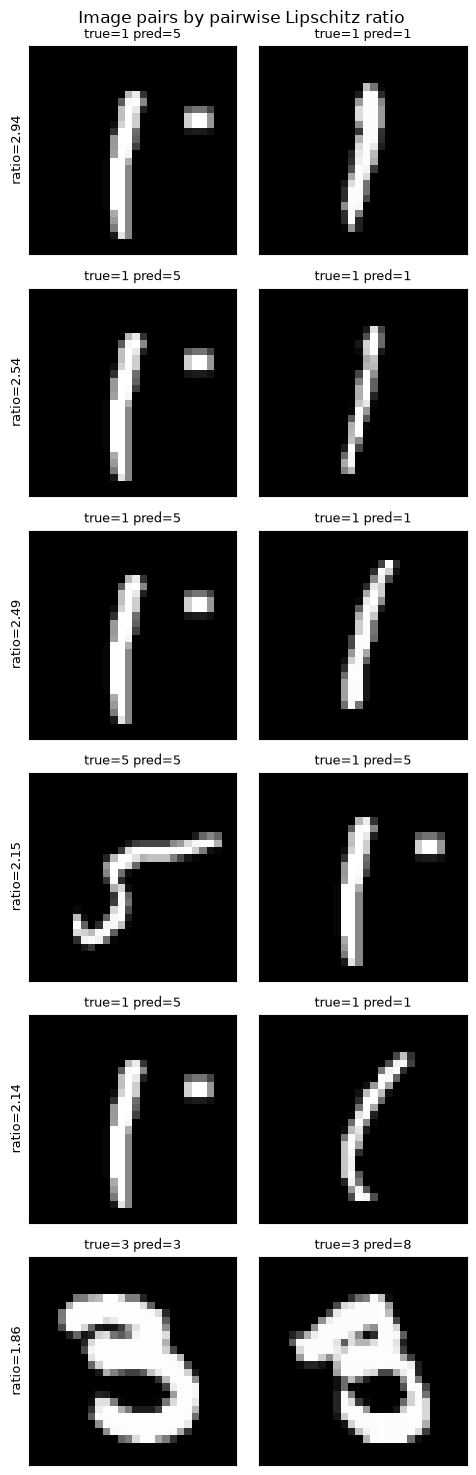

=== mlp ===
rank  true1  pred1  true2  pred2    ratio
   0      2      2      3      2   2.7766
   1      6      5      5      5   2.6147
   2      3      3      3      5   2.4233
   3      8      0      0      0   2.2856
   4      3      8      8      8   2.2490
   5      1      5      1      1   2.2326


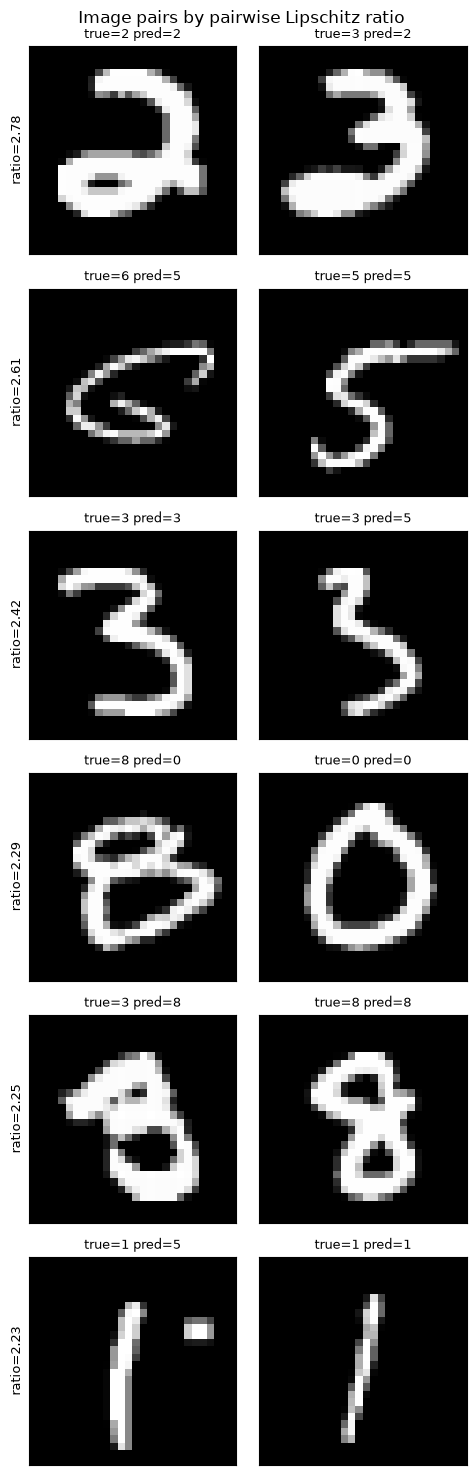

=== cnn ===
rank  true1  pred1  true2  pred2    ratio
   0      6      5      5      5   2.8021
   1      4      4      9      7   2.5869
   2      2      2      6      4   2.4105
   3      5      5      8      5   2.4050
   4      0      0      2      0   2.3630
   5      6      6      6      6   2.3519


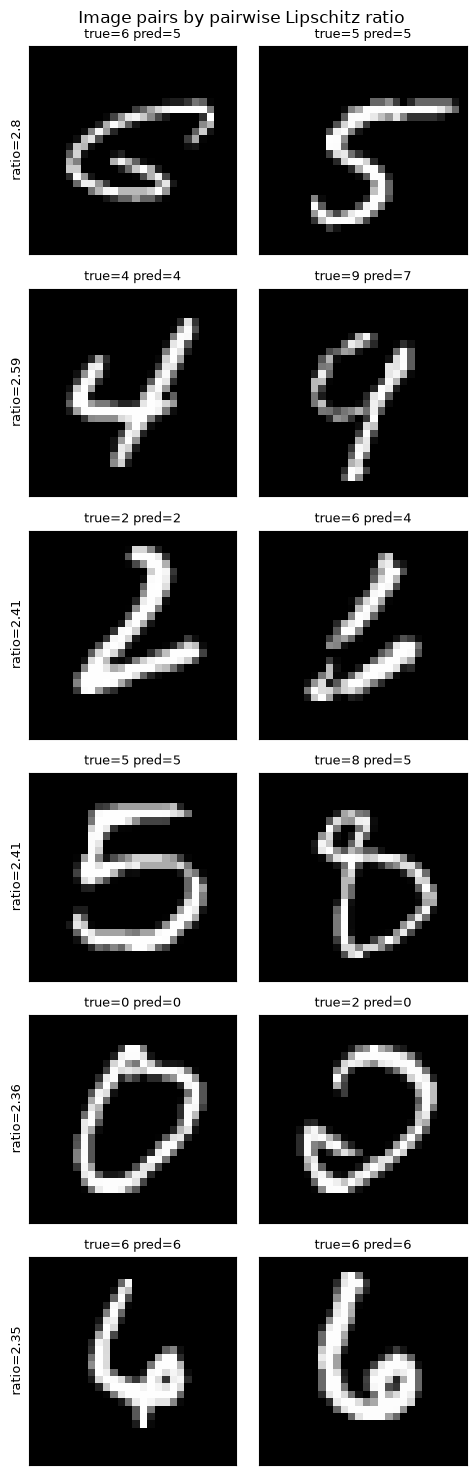

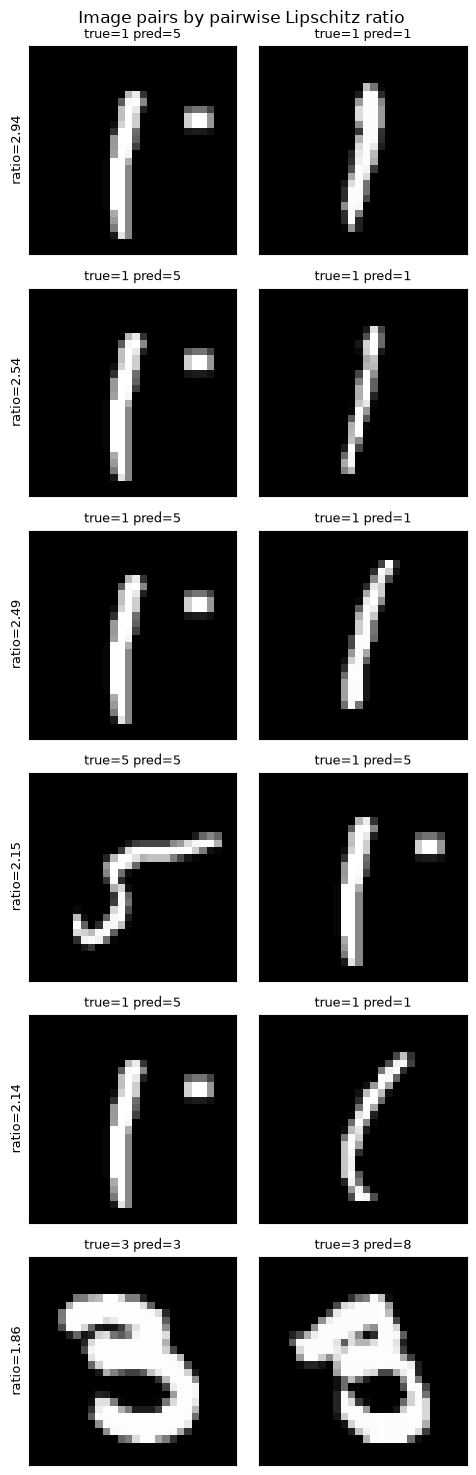

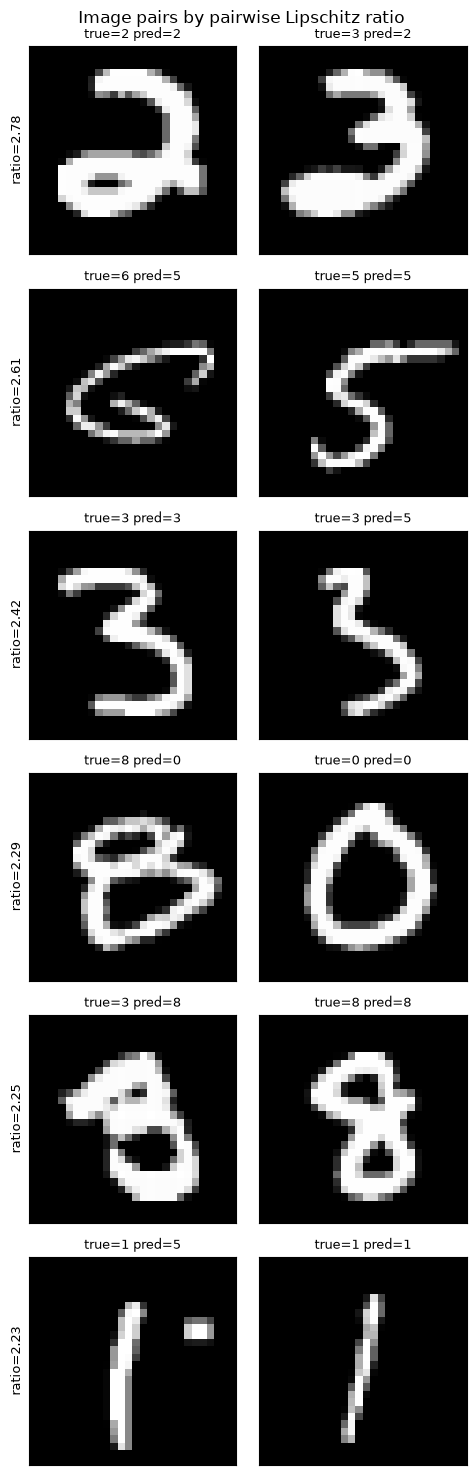

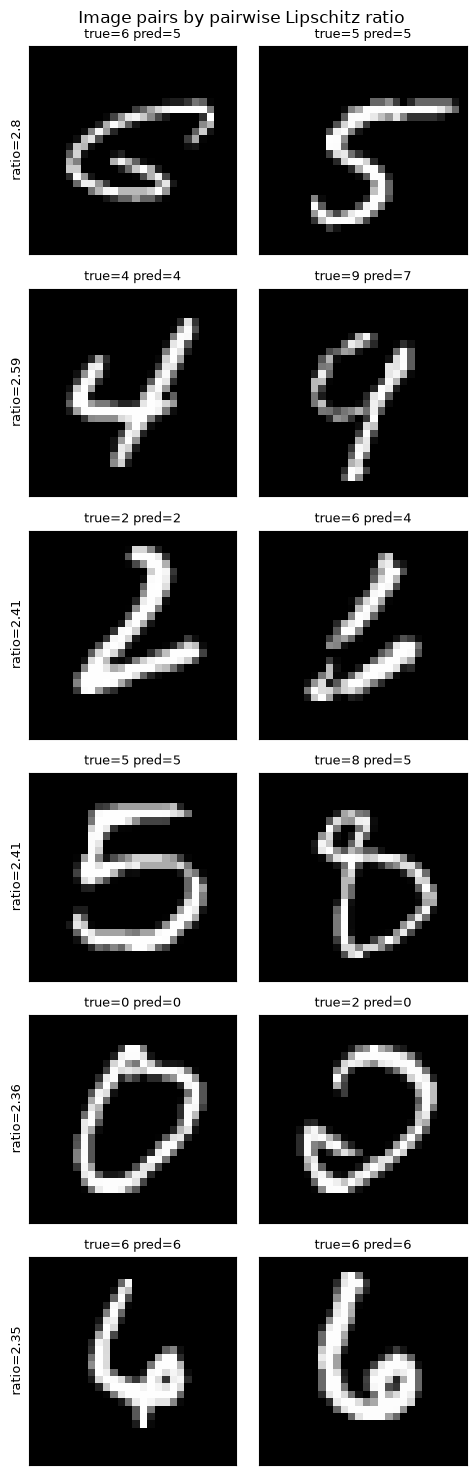

In [11]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_euclidean_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_{name}.png")
    display(fig)

## Mahalanobis distance: does it change the ratio-distribution picture?

Same question as [Mahalanobis vs. Euclidean: does the metric change the
estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
earlier in this notebook, now applied to the ratio-distribution/
near-neighbour checkpoint instead of the three sub-method estimates. Same
three models, same stratified 1000-point subset, same 5-nearest-neighbour
pairs (found in raw pixel space, so the neighbour structure itself doesn't
change -- only the ratio's denominator does), reusing the epsilon/precision
already selected above rather than re-running epsilon selection.

In [12]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 4b).
ratio_dist_mahalanobis_results = results["ratio_dist_mahalanobis_results"]

## Does the distribution shift near neighbours under Mahalanobis?

Under Euclidean distance (above), near-neighbour pairs sat modestly
*above* the full distribution for every model. Checked here, not assumed:
does the same hold under Mahalanobis, or does a metric derived from the
data's own pixel covariance behave differently?

model                 set                      shape       min       max      mean    median       std
logistic_regression   all pairs            (499500,)    0.0000    1.2492    0.1389    0.1136    0.1120
logistic_regression   near-neighbour         (5000,)    0.0001    1.0980    0.1078    0.0857    0.0933
mlp                   all pairs            (499500,)    0.0000    1.1762    0.1870    0.1550    0.1458
mlp                   near-neighbour         (5000,)    0.0000    0.9965    0.1537    0.1261    0.1233
cnn                   all pairs            (499500,)    0.0000    1.1682    0.1983    0.1694    0.1481
cnn                   near-neighbour         (5000,)    0.0001    0.8452    0.1508    0.1190    0.1249


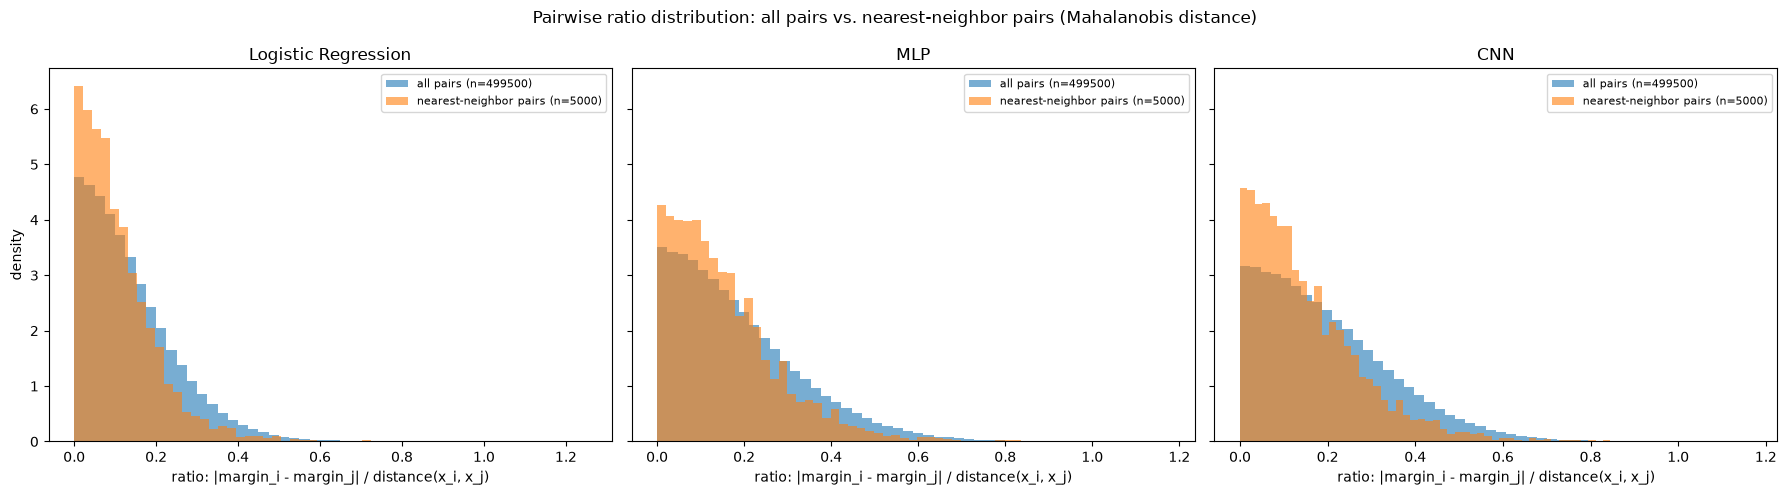

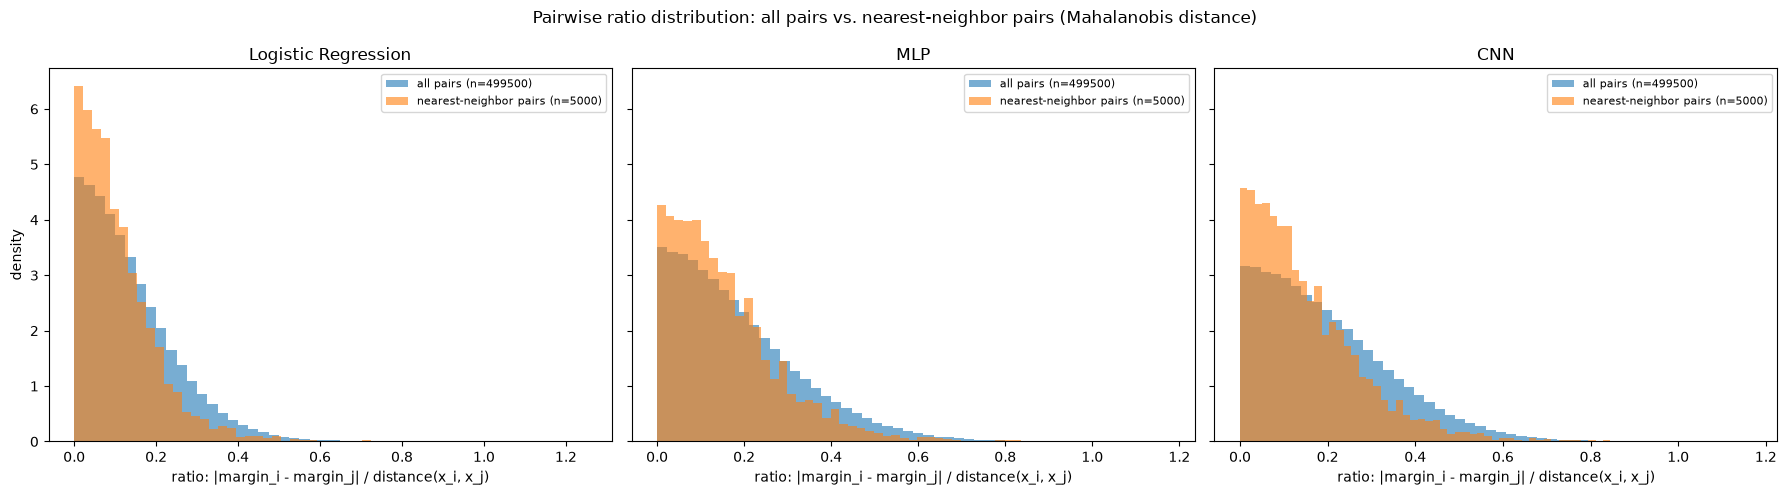

In [13]:
print(f"{'model':22s}{'set':18s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for name in ["logistic_regression", "mlp", "cnn"]:
    r = ratio_dist_mahalanobis_results[name]
    for label, arr in [("all pairs", r["all_pairs_ratio"].numpy()),
                        ("near-neighbour", r["near_neighbor_ratio"].numpy())]:
        print(f"{name:22s}{label:18s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
              f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist_mahalanobis = plots.plot_ratio_distribution(
    ratio_dist_mahalanobis_results, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_mahalanobis.png")
display(fig_ratio_dist_mahalanobis)

## Highest-ratio near-neighbour pairs (Mahalanobis)

Same gallery layout as the Euclidean version above, now for the
Mahalanobis distance. The absolute ratio values are much smaller here
(consistent with the Mahalanobis-vs-Euclidean sub-method comparison
earlier in this notebook, where every Mahalanobis estimate was smaller
too) -- the interesting comparison is *which* pairs and *what pattern*
show up, not the raw numbers, which aren't on the same scale as the
Euclidean ones.

=== logistic_regression (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio
   0      1      5      1      1   1.0980
   1      1      5      1      1   0.9431
   2      1      5      1      1   0.8951
   3      1      5      1      1   0.8019
   4      1      5      5      5   0.7188
   5      3      2      2      2   0.6400


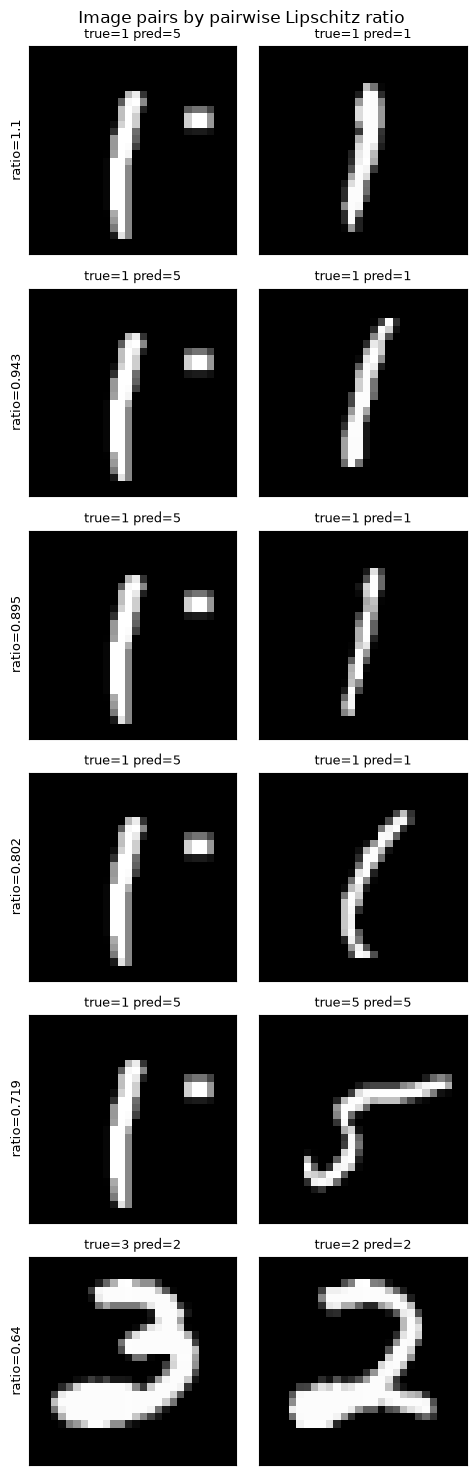

=== mlp (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio
   0      2      2      3      2   0.9965
   1      1      5      1      1   0.8326
   2      1      5      1      1   0.8182
   3      3      3      3      5   0.8087
   4      8      0      0      0   0.8065
   5      1      5      1      1   0.7867


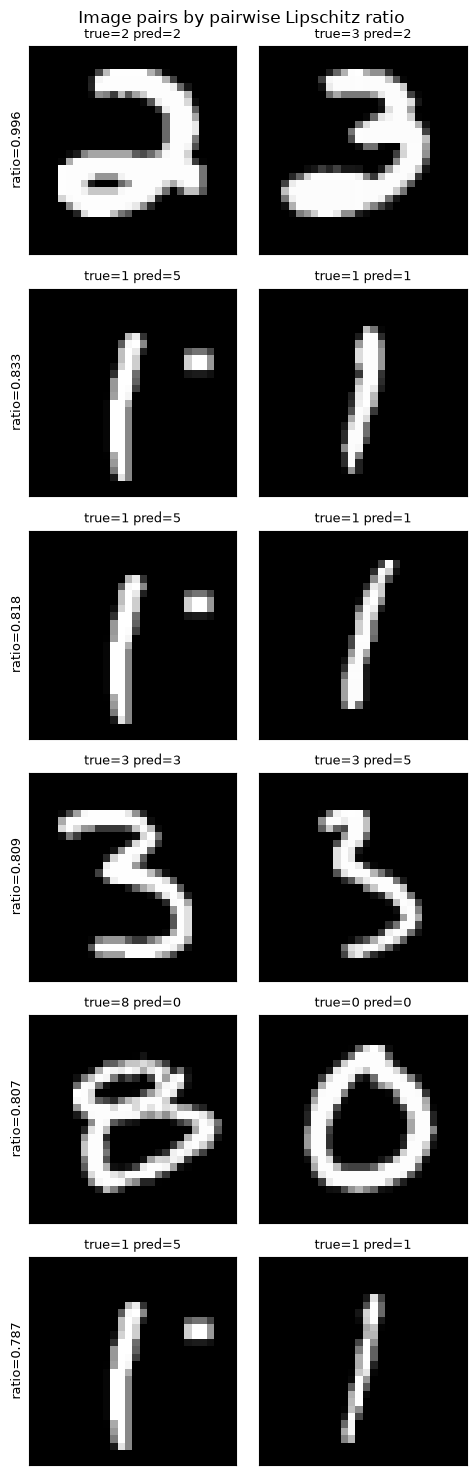

=== cnn (Mahalanobis) ===
rank  true1  pred1  true2  pred2    ratio
   0      4      4      9      7   0.8452
   1      6      5      5      5   0.8190
   2      8      5      5      5   0.8095
   3      3      3      3      3   0.7734
   4      6      4      2      2   0.7471
   5      2      0      0      0   0.7323


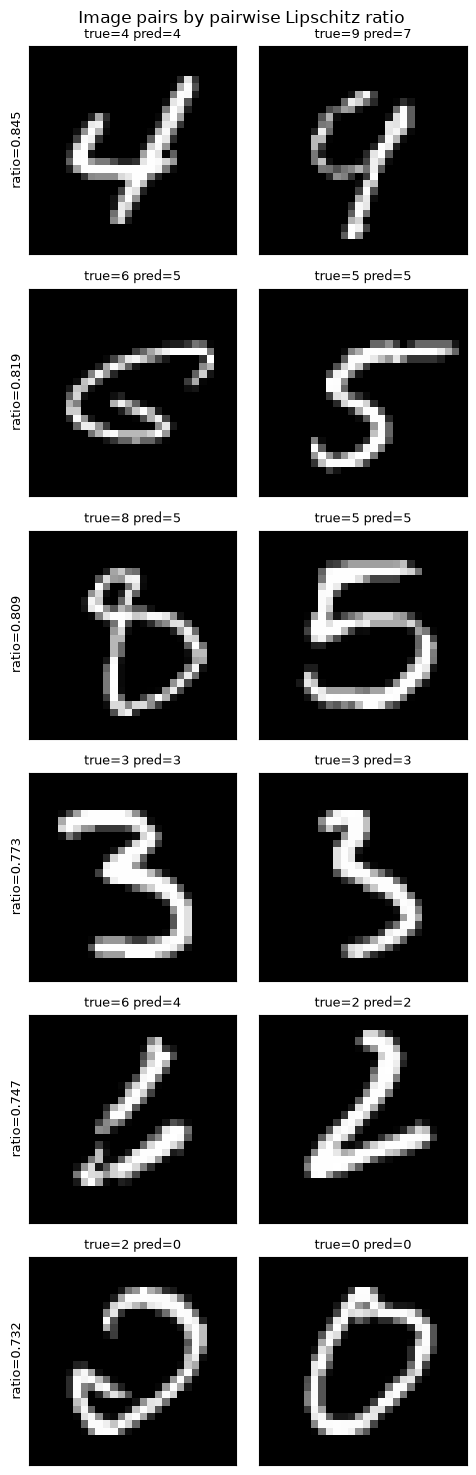

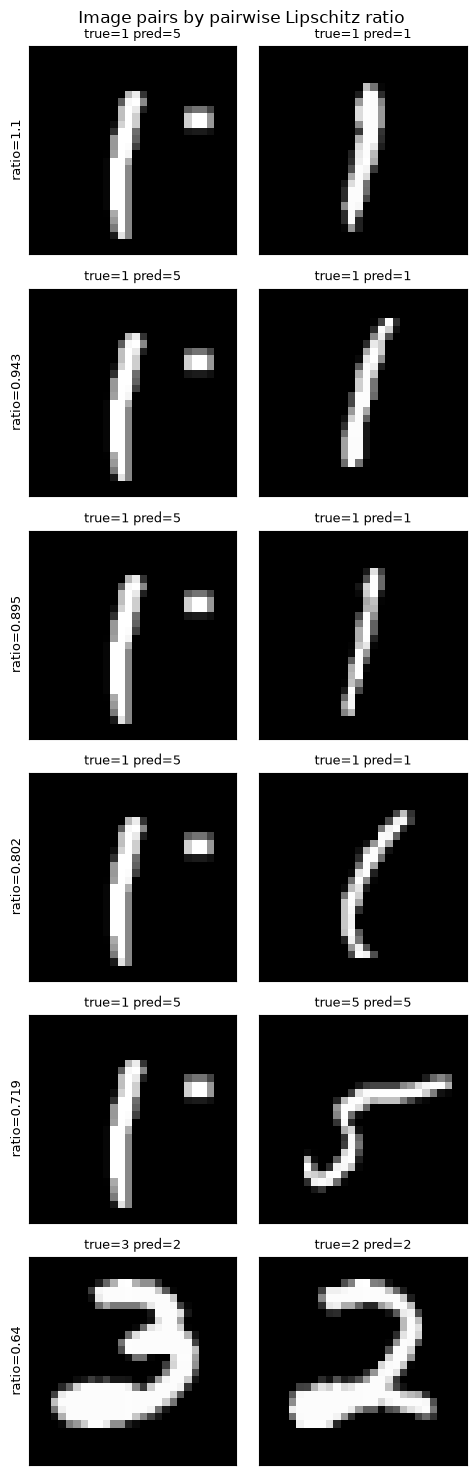

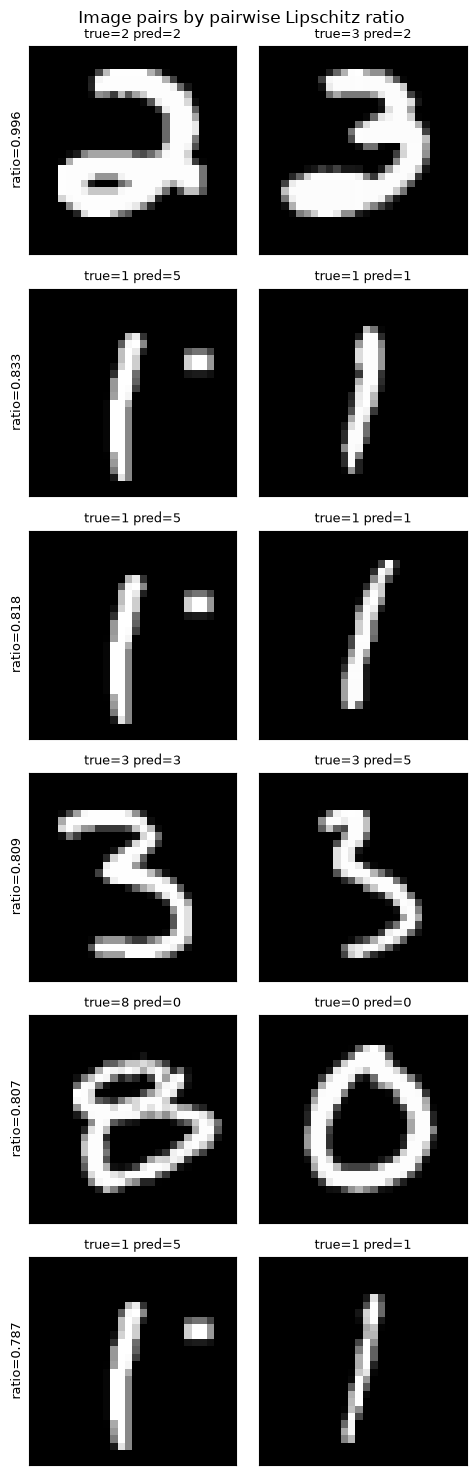

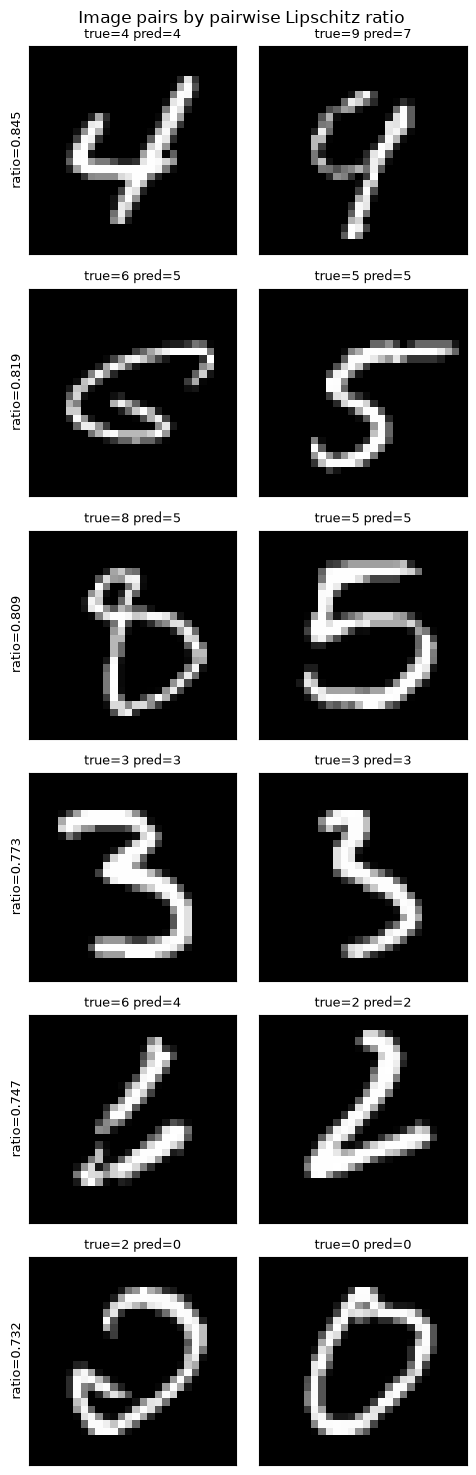

In [14]:
for name in ["logistic_regression", "mlp", "cnn"]:
    top_pairs = ratio_dist_mahalanobis_results[name]["top_near_neighbor_pairs"]

    print(f"=== {name} (Mahalanobis) ===")
    print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}")
    for rank, (img1, img2, true1, pred1, true2, pred2, ratio) in enumerate(top_pairs):
        print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}")

    fig = plots.plot_image_pairs(
        top_pairs, save_path=run_experiment.RESULTS_DIR / f"top_near_neighbor_pairs_mahalanobis_{name}.png")
    display(fig)

## Euclidean vs. Mahalanobis: does the metric change which pairs matter?

The same comparison as [Mahalanobis vs. Euclidean: does the metric change
the estimates?](#Mahalanobis-vs.-Euclidean:-does-the-metric-change-the-estimates?)
above, but for the ratio-distribution summary stats instead of the three
sub-method estimates.

**Finding, and it's the opposite of what the earlier panels in this
notebook might suggest by analogy**: under Euclidean distance,
near-neighbour pairs sit *above* the full distribution's mean for every
model (a 13-23% increase). Under Mahalanobis distance, that flips --
near-neighbour pairs sit *below* the full distribution's mean for every
model (a 14-21% decrease). This reversal is consistent across all three
models, not a one-off:

| model | Euclidean near/all mean ratio | Mahalanobis near/all mean ratio |
|---|---|---|
| logistic regression | 1.13 | 0.79 |
| MLP | 1.23 | 0.86 |
| CNN | 1.17 | 0.81 |

One plausible explanation, not confirmed here: the Mahalanobis distance
derives its notion of "closeness" from MNIST's own pixel covariance, so
directions where pixels vary a lot across the whole dataset count as
"large" steps and directions where they barely vary count as "small"
steps. Two images that are close together in raw pixel space
(near-neighbours) likely differ mainly along exactly those
high-variance, commonly-varying directions -- so their Mahalanobis
distance grows disproportionately relative to their Euclidean distance,
shrinking the ratio. This is the same kind of self-referential-metric
effect flagged in Experiment 1 (a metric built from the data's own
variance structure can end up dividing out part of the very signal it's
used to measure) -- worth keeping in mind rather than assuming the
Mahalanobis distance is a strict upgrade here just because it improved
things elsewhere in this notebook.

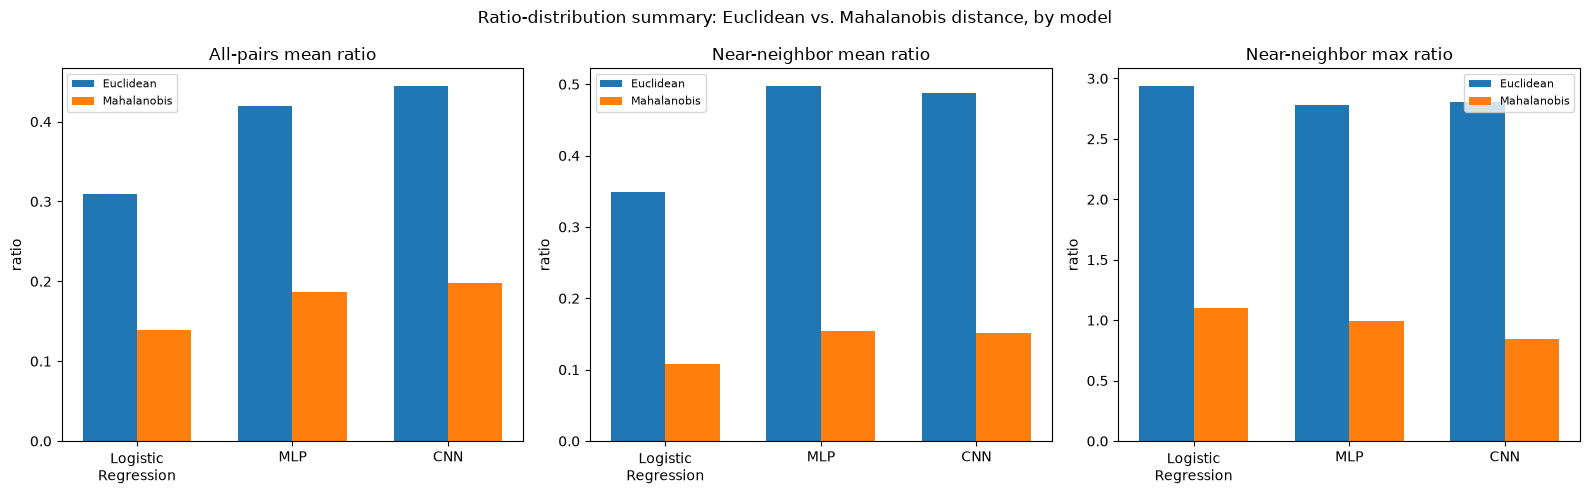

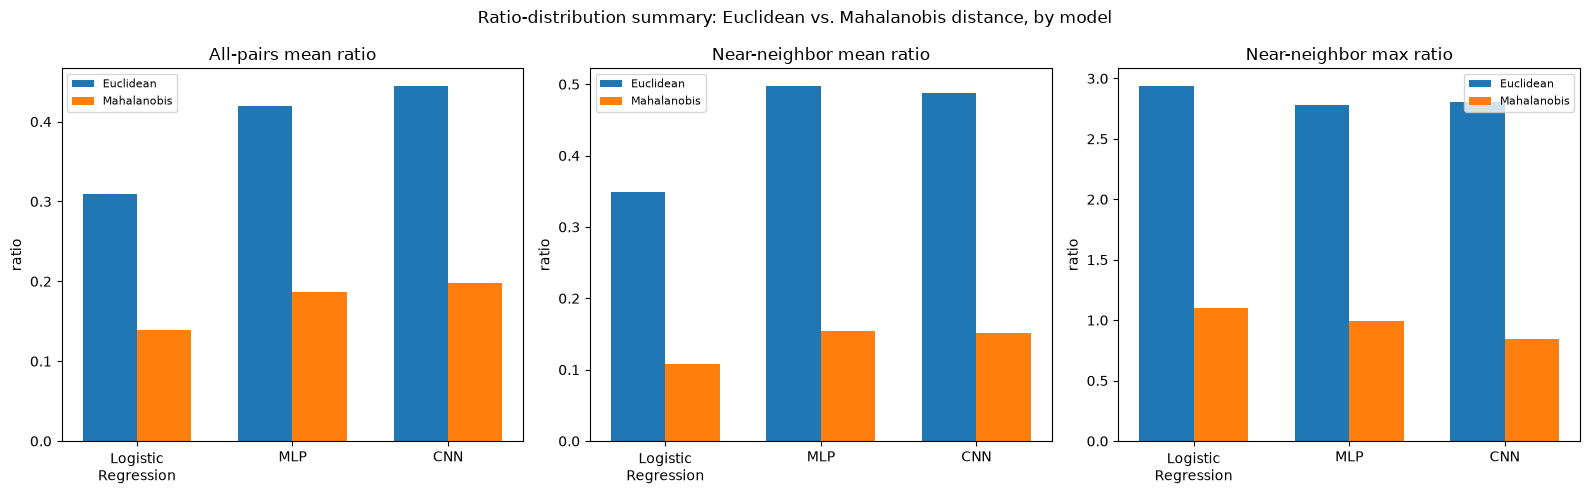

In [15]:
fig_ratio_dist_compare = plots.plot_ratio_distribution_euclidean_vs_mahalanobis(
    ratio_dist_euclidean_results, ratio_dist_mahalanobis_results,
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution_euclidean_vs_mahalanobis.png")
display(fig_ratio_dist_compare)

## Summary and status

See `README.md` in this folder for the full write-up, including the
actual measured numbers behind the plots above, the design decisions made
along the way (activation choice, pair-sampling strategy, the precision
vs. its inverse convention in the gradient-norm dual norm, why ridge
regularization was used before trying PCA truncation, how epsilon was
selected), and an honest account of what was and wasn't expected --
including that the three sub-methods agree much less closely here than
they did in Experiment 1's toy setting, and that this gap widens rather
than narrows under the Mahalanobis metric. The ratio-distribution
checkpoint extends that same honesty: under Euclidean distance,
near-neighbour pairs sit modestly *above* the full distribution for all
three models, and each model's top pairs are genuine cross-digit
confusions rather than degenerate matches -- but the *specific* confusable
pairs differ by model (logistic regression: 9/3, 2/4, 0/7; MLP: 2/7, 7/1,
1/6; CNN: 6/5, 8/2, 8/0, 7/2). Under Mahalanobis distance, that near-vs-all
relationship *reverses* -- near-neighbour pairs sit *below* the full
distribution for all three models, plausibly because the Mahalanobis
metric's own covariance-derived notion of "large step" already accounts
for the directions along which visually-similar images tend to differ
(the same self-referential-metric caution Experiment 1 raised). Both
distances and all three models are now covered for this checkpoint.

This is Experiment 2 of the Lipschitz-diagnostics project. Adversarial
examples, robustness mitigations, and Fashion-MNIST are explicitly out of
scope here and may be the subject of a later experiment.